In [1]:
%cd /Users/lucas/repositories/degeneracy_distillery/

/Users/lucas/repositories/degeneracy_distillery


In [2]:
pwd

'/Users/lucas/repositories/degeneracy_distillery'

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from pyoperon.sklearn import SymbolicRegressor
import multiprocessing
import csv
from sklearn.metrics import r2_score
import string
import sys,os
import sympy
import scipy
import esr.generation.generator

import jax
import jax.numpy as jnp

from tqdm import tqdm as tq


sys.path.insert(0, ('../degeneracy_distillery/degeneracy_distillery'))

In [7]:
pwd

'/Users/lucas/repositories/degeneracy_distillery'

In [9]:
# from postprocessing_utils import load_and_process_data, process_ensemble_rotation

# Import preprocessing (rotations, data loading)
from preprocessing_utils import (
    load_and_process_data,
    process_ensemble_rotation,
    flatten_with_numerical_jacobian,
    batch_flatten_fisher,
    rotate_coords,
    load_and_process_data,
    weighted_std
)

# Import postprocessing (SR optimization)
from postprocessing_utils import (
    lossfn_jac_jax,
    get_component,
    get_pruned_expressions,
    get_pruned_expressions_final,
    check_flattening,
    make_check_flattening_fn,
)

# Create loss function
# _lossfn = lambda a: lossfn_jac_jax(
#     a, all_pars, all_fns, all_linear_pars, all_linear_inds,
#     X=X, Fs=Fs, n_params=n_params, delta=0.2, alpha=1.5
# )

# Option 1: Load and process in one call
data = load_and_process_data(
    datapath="",
    filename="/Users/lucas/repositories/degeneracy_distillery/data/gauss_mu_sigma_flatten_neural_23_02.npz",
      #/Users/lucas/repositories/degen_discovery/simple_problems/flattened_coords_little_sigma.npz",
    num_samps=4000,
    process_ensemble=True,  # <-- enables full processing
    n_d=1.0,
    verbose=True,
    y_reference_index=None,
    use_var=True
)

# Access results directly:
y = data['y']           # Weighted average outputs (masked)
y_std = data['y_std']   # Weighted std (masked)
dy = data['dy']         # Weighted average Jacobian (masked)
dy_sr = data['dy_sr']   # Weighted average rotated Jacobian
Fs = data['Fs']         # Weighted average Fisher
X = data['X']           # Parameters (masked)

norm_factor = data['norm_factor']

n_params = X.shape[-1]

# Option 2: Two-step process (more control)
# data = load_and_process_data(datapath="./", filename="fake_cmb_flatten_03_09_sum.npz", process_ensemble=False)
# result = process_ensemble_rotation(
#     datafile=data['datafile'],
#     randidx=data['randidx'],
#     Favg=data['Favg'],
#     best_model_idx=data['best_model_idx'],
#     n_d=1.0
# )

best model 15
Network 0: y.min() = 3.169616, weight = 1.7
thetastar [-0.03483295  3.6325028 ]
using var F
  Shapes: y=(4000, 2), X=(4000, 2)
Network 1: y.min() = 2.031438, weight = 1.9
thetastar [-0.03483295  3.6325028 ]
using var F
  Shapes: y=(4000, 2), X=(4000, 2)
Network 2: y.min() = 0.738700, weight = 2.1
thetastar [-0.03483295  3.6325028 ]
using var F
  Shapes: y=(4000, 2), X=(4000, 2)
Network 3: y.min() = 5.467503, weight = 1.4
thetastar [-0.03483295  3.6325028 ]
using var F
  Shapes: y=(4000, 2), X=(4000, 2)
Network 4: y.min() = 1.732053, weight = 1.9
thetastar [-0.03483295  3.6325028 ]
using var F
  Shapes: y=(4000, 2), X=(4000, 2)
Network 5: y.min() = 0.401477, weight = 2.1
thetastar [-0.03483295  3.6325028 ]
using var F
  Shapes: y=(4000, 2), X=(4000, 2)
Network 6: y.min() = 0.885528, weight = 2.1
thetastar [-0.03483295  3.6325028 ]
using var F
  Shapes: y=(4000, 2), X=(4000, 2)
Network 7: y.min() = 2.059817, weight = 1.7
thetastar [-0.03483295  3.6325028 ]
using var F
  Sha

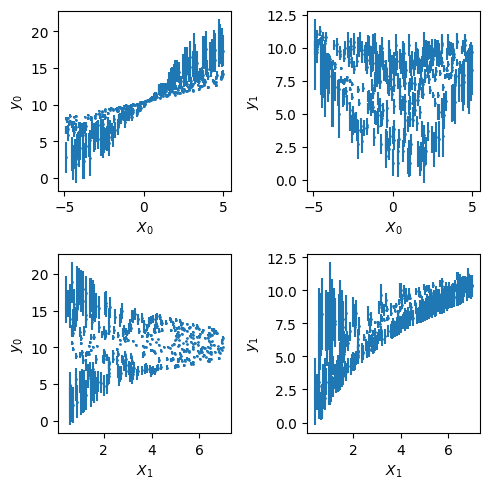

In [10]:
# create scatterplot to see how y responds to X

fig, axs = plt.subplots(n_params, n_params, figsize=(5,5))

skip=10

for i in range(X.shape[-1]):
    for j in range(y.shape[-1]):
        
        # row, column
        axs[i,j].errorbar(X[::skip,i], y[::skip, j], yerr=y_std[::skip, j], label='', fmt='o', markersize=1)

        axs[i,j].set_xlabel(r"$X_%d$"%(i))
        axs[i,j].set_ylabel(r"$y_%d$"%(j))

plt.tight_layout()
plt.show()

In [7]:
y[0]

array([5.5862017, 3.7841089], dtype=float32)

In [8]:
np.cov(y, rowvar=False).shape

Text(0, 0.5, '$y$')

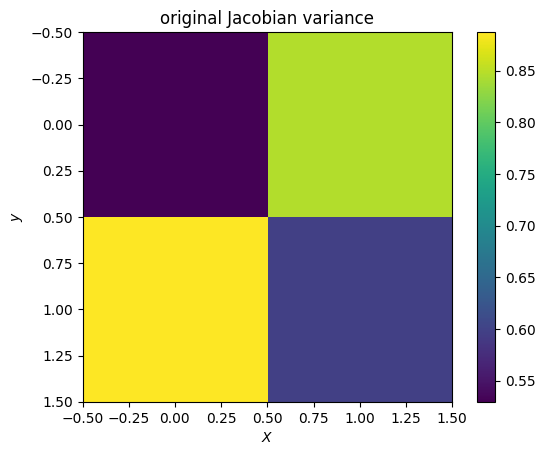

In [11]:
plt.imshow(dy.std(0))
plt.colorbar()
plt.title('original Jacobian variance')
plt.xlabel("$X$")
plt.ylabel("$y$")

Text(0, 0.5, '$y$')

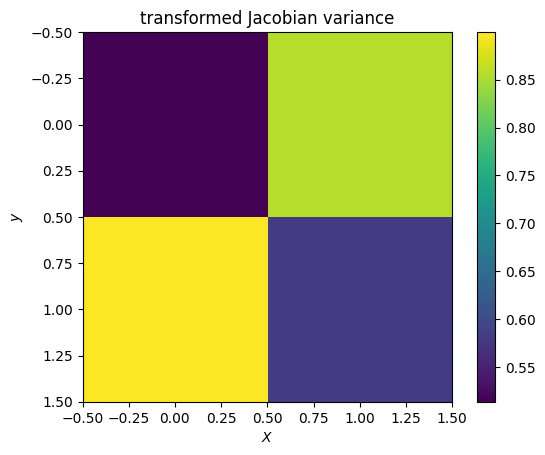

In [10]:
plt.imshow(dy_sr.std(0))
plt.colorbar()
plt.title('transformed Jacobian variance')
plt.xlabel("$X$")

plt.ylabel("$y$")

Text(0, 0.5, '$y$')

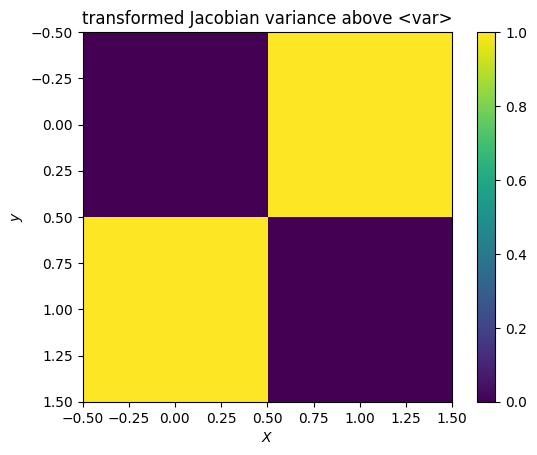

In [12]:
plt.imshow(dy_sr.var(0) > (dy_sr.var(0).mean()))
plt.colorbar()
plt.title('transformed Jacobian variance above <var>')
plt.xlabel("$X$")
plt.ylabel("$y$")

Text(0, 0.5, '$y$')

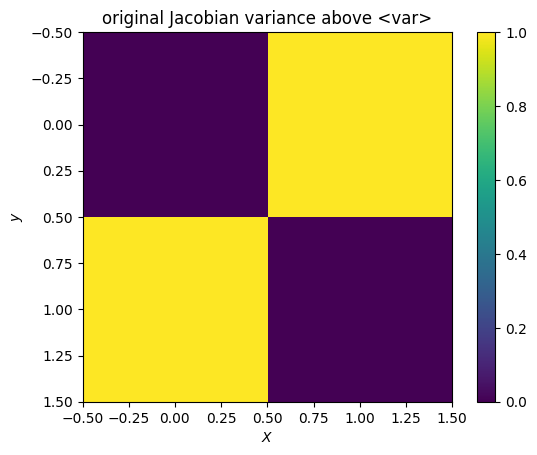

In [12]:
plt.imshow(dy.std(0) > (dy.std(0).mean()))
plt.colorbar()
plt.title('original Jacobian variance above <var>')
plt.xlabel("$X$")
plt.ylabel("$y$")

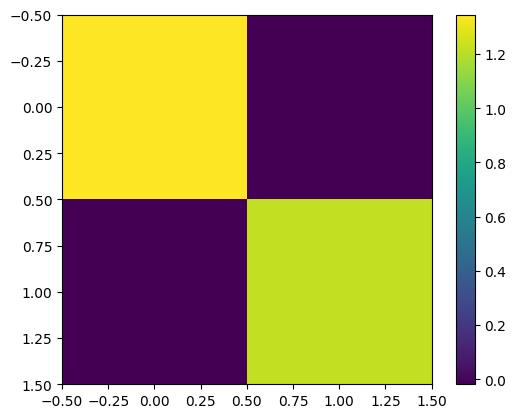

In [13]:
# foo = dy_sr / np.sqrt(0.5)
plt.imshow(jax.vmap(flatten_with_numerical_jacobian)(dy, Fs).mean(0))
plt.colorbar()

Text(0, 0.5, '$\\langle\\eta_{0,j}\\rangle$')

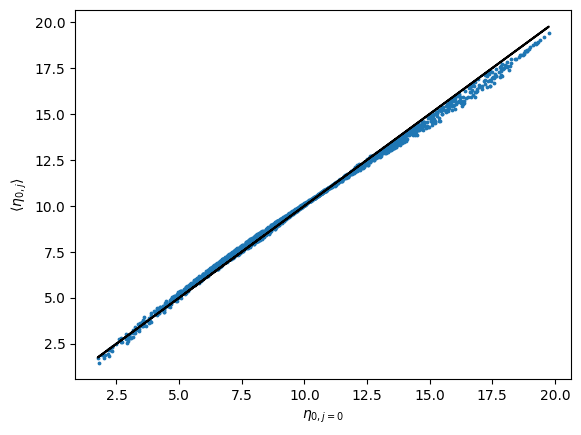

In [13]:
plt.scatter(data['ys'][0, ::2, 0], np.average(data['ys'][1:, ::2, 0], axis=0, \
                            weights=(data['ensemble_weights'][1:])), s=3) 

plt.plot(data['ys'][0, ::2, 0],data['ys'][0, ::2, 0], c='k')
plt.xlabel(r"$\eta_{0,j=0}$")
plt.ylabel(r"$\langle\eta_{0,j}\rangle$")

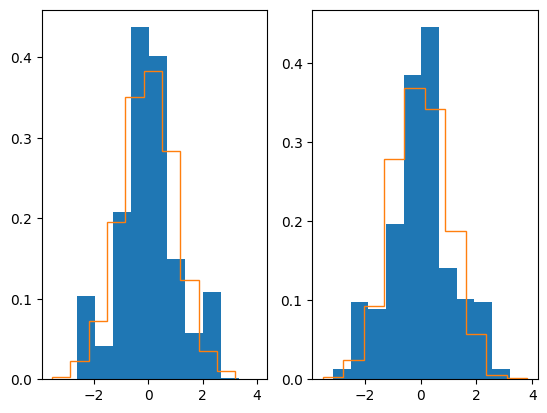

In [14]:
fig,axs = plt.subplots(1,2)
axs = axs.flatten()

for i,ax in enumerate(axs):
    ax.hist(((data['ys'] - y) / y_std)[:, :, i].flatten(), density=True)
    ax.hist(np.random.normal(size=(2000,)).flatten(), histtype='step', density=True)

In [15]:
(np.sqrt(np.linalg.det(Fs).mean()))

np.float32(4.1304636)

# try out symbolic fitting code

In [ ]:
from sr_utils import fit_and_analyze_sr

# Split your data
# halfx = X.shape[0] // 2
# X_train, X_val = X[:halfx], X[halfx:]
# y_train, y_val = y[:halfx], y[halfx:]
# Fs_train, Fs_val = Fs[:halfx], Fs[halfx:]
# dy_sr_train, dy_sr_val = dy_sr[:halfx], dy_sr[halfx:]
# y_std_train, y_std_val = y_std[:halfx], y_std[halfx:]
# ... same for other arrays

# Run complete pipeline
parent_dir = './ex_1/'

# Simple! Just pass your full arrays
mdl_coords, frob_coords, analysis, split_data = fit_and_analyze_sr(
    X, y, y_std, dy_sr, Fs,
    parent_dir=parent_dir,
    n_params=2,
    allowed_symbols='add,mul,pow,constant,variable,exp,sqrt,log',  # no log
    max_length=20,              # shorter equations
    time_limit=60*2,             # per component
    objectives=['rmse', 'length'],  # RMSE instead of R2
    equation_set='pareto'
)

print("Best MDL coordinates:", mdl_coords)
print("Best Frob coordinates:", frob_coords)


Fitting component 1 of 2 (index 0)
X train shape: (2000, 2), y train shape: (2000,)
Fitting...


In [101]:
split_data['X_test'].shape

In [102]:
# Access test data for further analysis
X_test = split_data['X_test']
y_test = split_data['y_test']
Fs_test = split_data['Fs_test']
y_std_test = split_data['y_std_test']
dy_sr_test = split_data['dy_sr_test']


In [103]:
analysis

{'latex': [['X_{1} b_{1} b_{2} + b_{0}',
   'b_{0} + b_{1} e^{X_{1} b_{2}}',
   'b_{0} + b_{1} \\left(X_{2} b_{2}\\right)^{X_{1} b_{3}}',
   'X_{1} b_{1} b_{3} e^{X_{2} b_{2}} + b_{0}',
   'X_{1} b_{1} b_{2}^{X_{2} b_{3}} b_{4} + b_{0}',
   'b_{0} + b_{1} \\left(X_{1} b_{3} e^{X_{2} b_{2}} + X_{1} b_{4}\\right)',
   'X_{1} b_{1} b_{4} \\left(e^{X_{2} b_{2}}\\right)^{e^{X_{1} b_{3}}} + b_{0}',
   'X_{1} b_{1} b_{5} \\left(X_{1}^{2} b_{3} b_{4} + e^{X_{2} b_{2}}\\right) + b_{0}',
   'X_{1} b_{1} b_{5} \\left(e^{X_{1} b_{3}}\\right)^{X_{1} b_{4}} e^{X_{2} b_{2}} + b_{0}'],
  ['X_{2} b_{1} b_{2} + b_{0}',
   'b_{0} + b_{1} \\left(X_{2} b_{2}\\right)^{0.5}',
   'b_{0} + b_{1} \\left(X_{2} b_{2}\\right)^{b_{3}}',
   'b_{0} + b_{1} \\left(X_{2} b_{2} + e^{X_{1} b_{3}}\\right)',
   'b_{0} + b_{1} \\left(X_{1}^{2} b_{2} b_{3} + X_{2} b_{4}\\right)',
   'b_{0} + b_{1} \\log{\\left(X_{1}^{2} b_{2} b_{3} + X_{2} b_{4} \\right)}',
   'b_{0} + b_{1} \\left(X_{1}^{2} b_{3} b_{4} + X_{2} b_{2}\\right)

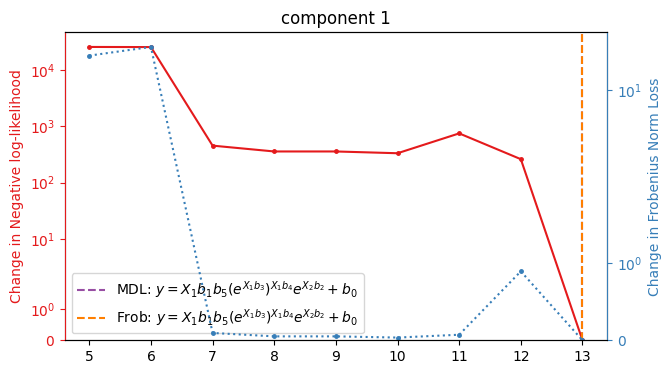

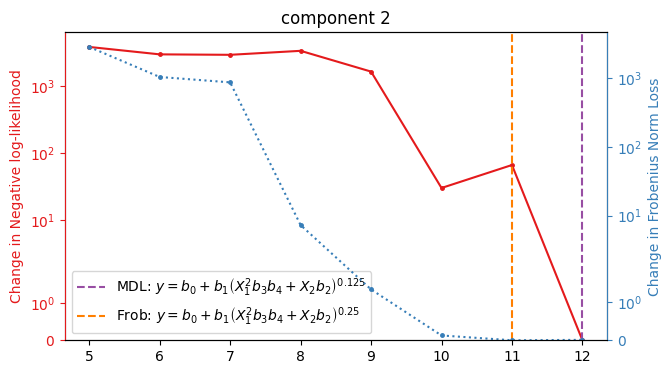

In [160]:
# components_to_fit = [0,1]

# Access the best equation indices for component 0
ibest_mdl = analysis['ibest_mdl'][0]    # index of best MDL equation
ibest_frob = analysis['ibest_frob'][0]  # index of best Frob equation

# Get the actual equations at those indices
best_mdl_eq = analysis['equations'][0][ibest_mdl]
best_frob_eq = analysis['equations'][0][ibest_frob]

# Access other metrics at those indices
mdl_complexity = analysis['complexity'][0][ibest_mdl]
frob_complexity = analysis['complexity'][0][ibest_frob]



n_components = 2

both_comp_latex = []
both_comp_eqs = []
both_comp_frobloss = []
both_comp_logL = []
both_comp_DL = []


max_complexity_thresh = 15

for i in range(n_components):

    idx = i


    # Access the best equation indices for component 0
    ibest_mdl = analysis['ibest_mdl'][i]    # index of best MDL equation
    ibest_frob = analysis['ibest_frob'][i]  # index of best Frob equation

    # Get the actual equations at those indices
    best_mdl_eq = analysis['equations'][i][ibest_mdl]
    best_frob_eq = analysis['equations'][i][ibest_frob]

    # Access other metrics at those indices
    mdl_complexity = analysis['complexity'][i][ibest_mdl]
    frob_complexity = analysis['complexity'][i][ibest_frob]
    


    fig, ax1 = plt.subplots(1, 1, figsize=(7,4), sharex=True)
    cm = plt.get_cmap('Set1')
    ax2 = ax1.twinx()
    
    #ax1.plot(complexity, pareto_DL, marker='.', color=cm(0), markersize=5, )
    # ax2.plot(complexity, pareto_logL, marker='.', color=cm(1), markersize=5, ls=':')
    ax1.plot(analysis['complexity'][i], analysis['logL'][i], marker='.', color=cm(0), markersize=5, )
    ax2.plot(analysis['complexity'][i], analysis['frobloss'][i], marker='.', color=cm(1), markersize=5, ls=':')


    #ax1.set_ylabel('Change in Description Length')
    # ax2.set_ylabel('Change in Negative log-likelihood')
    ax1.set_ylabel('Change in Negative log-likelihood')
    ax2.set_ylabel('Change in Frobenius Norm Loss')
    ax1.yaxis.label.set_color(cm(0))
    ax1.tick_params(axis='y', colors=cm(0))
    ax2.spines['left'].set_color(cm(0))

    ax2.yaxis.label.set_color(cm(1))
    ax2.tick_params(axis='y', colors=cm(1))
    ax2.spines['right'].set_color(cm(1))

    ax1.set_yscale('symlog')
    ax2.set_yscale('symlog')
    ax1.set_ylim(0, None)
    ax2.set_ylim(0, None)

    pareto_latex = analysis['latex'][i]
    #ax1.axvline(complexity[pysr_ibest], color=cm(2), ls=':', label=r'Score: $y = %s$'%all_latex[pysr_ibest])
    ax1.axvline(analysis['complexity'][i][ibest_mdl], color=cm(3), ls='--', label=r'MDL: $y = %s$'%pareto_latex[ibest_mdl])
    ax1.axvline(analysis['complexity'][i][ibest_frob], color=cm(4), ls='--', label=r'Frob: $y = %s$'%pareto_latex[ibest_frob])

    ax1.legend()
    plt.title("component %d"%(idx + 1))
    plt.show()
    #fig.savefig('function_ranking.png', bbox_inches='tight', facecolor='white')


In [161]:
mdl_coords

['(10.347089 + (1.000000 * ((exp(((-0.243016) * X2)) * (exp((0.030135 * X1)) ^ ((-0.422953) * X1))) * (2.789157 * X1))))',
 '((-26.317766) + (4.377672 * sqrt(sqrt(sqrt(((2969345.250000 * X2) + ((119.890717 * X1) * (3511.637695 * X1))))))))']

# post-process SR expressions

In [106]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [107]:
pwd

'/Users/lucas/repositories/degeneracy_distillery'

In [112]:
# Import postprocessing (SR optimization)
from postprocessing_utils import (
    lossfn_jac_jax,
    get_component,
    get_pruned_expressions,
    get_pruned_expressions_final,
    check_flattening,
    make_check_flattening_fn,
    get_Q_jax, construct_M
)




### demo


In [113]:
all_pars = []
all_linear_pars = []
all_fns = []
all_linear_inds = []
all_param_dicts = []
all_xs = []
all_bs = []

all_expr = []

all_linear_labels = []

for i in range(n_params):
    # lab, expr, prs, _x, _b, eq_fn, oldexpr, nodes = get_component(mdl_coordinates[i], i)

    lab, expr, prs, linear_prs, _x, _b, eq_fn, param_dict, linear_inds = get_component(mdl_coords[i], i, X=X, module="jax")
    all_pars.append(prs)
    all_linear_pars.append(linear_prs)
    all_fns.append(eq_fn)
    all_xs.append(_x)
    all_bs.append(_b)
    all_linear_inds.append(linear_inds)
    all_param_dicts.append(param_dict)
    all_expr.append(expr)

    all_linear_labels.append([_b[l] for l in linear_inds])



In [114]:
import numpy as np
from scipy.optimize import minimize

def sparse_rotation_loss(A_flat, M, lambda_ortho=1.0, alpha=1.0):
    """
    A_flat: Flattened rotation matrix A (size N*N)
    M:      Coefficient matrix (size N*T)
    lambda_ortho: Weight for orthogonality constraint
    alpha:  Scaling factor for log-cosh (controls steepness)
    """
    # 1. Reshape A back to square matrix
    dim = int(np.sqrt(len(A_flat)))
    A = A_flat.reshape((dim, dim))
    # A = get_Q_jax(A)
    
    # 2. Calculate Rotated Factors (y_pred components)
    # y_pred = A @ M (The projection we want to be sparse)
    transformed_M = A @ M
    
    # 3. Sparsity Loss (Log-Cosh approximation of L1)
    # Behaving like L2 near 0 and L1 away from 0. Differentiable.
    sparsity_loss = np.sum(np.log(np.cosh(alpha * transformed_M))) / alpha
    
    # 4. Orthogonality Constraint (Soft Penalty)
    # Forces A^T @ A to be close to Identity
    I = np.eye(dim)
    ortho_loss = np.linalg.norm(A.T @ A - I, ord='fro')**2
    
    # 5. Total Loss
    total_loss = sparsity_loss + (lambda_ortho * ortho_loss)
    
    return total_loss

# --- Example Usage ---

# 1. Setup Synthetic Data
np.random.seed(67)
N_dim = n_params   # Dimension of the basis (rows of M)
T_samples = 100 # Number of samples (cols of M)

# Create a random coefficient matrix M (dense initially)
# M = np.random.randn(N_dim, T_samples)
M = construct_M(all_linear_pars, n_params=n_params)

# 2. Initialize A
# Start with Identity or a random orthogonal matrix
# A_init = np.eye(N_dim).flatten()
A_init = get_Q_jax((np.random.randn(n_params*n_params)* (2./n_params**2)).reshape(n_params, n_params)).flatten()

# 3. Optimization Configuration
# lambda_ortho: How hard to enforce rotation constraint vs sparsity
# alpha: Higher values make log-cosh closer to true L1 (but harder to optimize)
loss_args = (M, 4.0, 1.5) 

print("Optimizing...")
result = minimize(
    fun=sparse_rotation_loss,
    x0=A_init,
    args=loss_args,
    method='L-BFGS-B',
    options={'disp': True, 'maxiter': 100000}
)

# 4. Extract Results
A_opt = result.x.reshape((N_dim, N_dim))
# A_opt = get_Q_jax(A_opt)
M_sparse = A_opt @ M

print("\nOptimization Success:", result.success)
print(f"Final Loss: {result.fun:.4f}")

# Check Orthogonality (Should be close to Identity)
ortho_check = A_opt.T @ A_opt
print("\nCheck A^T @ A (Diagonal should be ~1.0):")
print(np.round(np.diag(ortho_check), 4))

# Visual check of Sparsity (Kurtosis increases if sparsity increases)
from scipy.stats import kurtosis
kurt_original = np.mean(kurtosis(M, axis=1))
kurt_rotated = np.mean(kurtosis(M_sparse, axis=1))
print(f"\nAvg Kurtosis (Original M): {kurt_original:.2f}")
print(f"Avg Kurtosis (Rotated M):  {kurt_rotated:.2f} (Higher is sparser)")

Aopt = A_opt

Optimizing...

Optimization Success: True
Final Loss: 8.0000

Check A^T @ A (Diagonal should be ~1.0):
[0. 0.]

Avg Kurtosis (Original M): 0.02
Avg Kurtosis (Rotated M):  -0.69 (Higher is sparser)


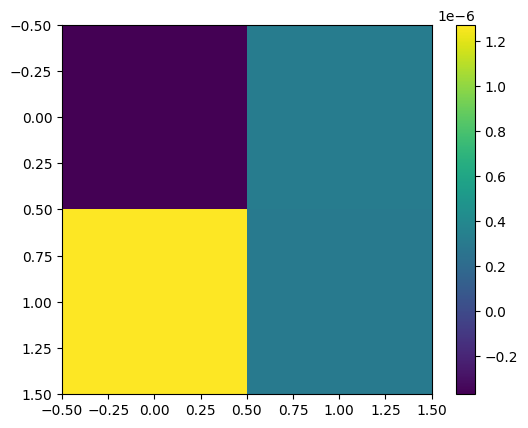

In [115]:
plt.imshow(Aopt)
plt.colorbar()

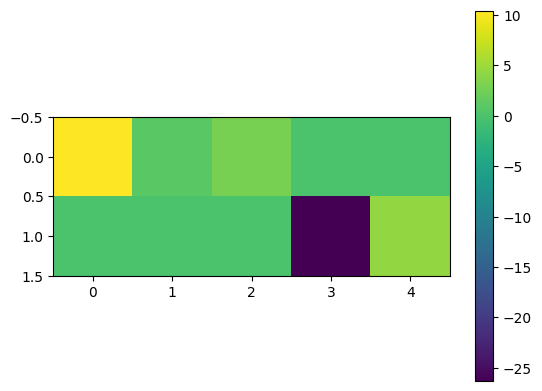

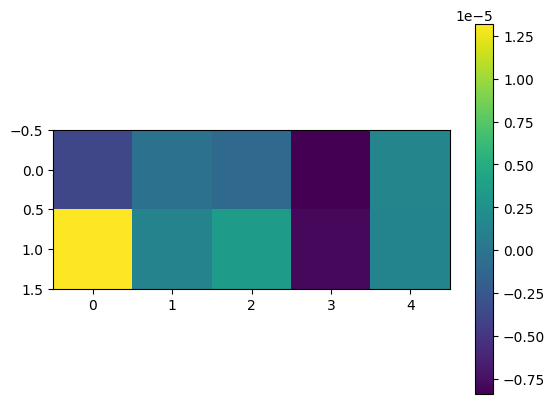

In [116]:
plt.imshow(M)
plt.colorbar()
plt.show()
plt.imshow(M_sparse)
plt.colorbar()
plt.show()

In [40]:
_lossfn = lambda a: lossfn_jac_jax(a, all_pars, all_fns, all_linear_pars, all_linear_inds, parts=True, X=X, Fs=Fs, n_params=n_params)

_lossfn(Aopt), _lossfn(np.eye(n_params))

((Array(86.74094, dtype=float32),
  Array(0.10227925, dtype=float32),
  Array(20.555483, dtype=float32)),
 (Array(62.769047, dtype=float32),
  Array(0.10627331, dtype=float32),
  Array(41.661922, dtype=float32)))

In [41]:
all_linear_pars, mdl_coords

([array([ 4.0000000e-06,  1.0000000e+00,  1.0631649e+01,  2.2839000e+00,
         -6.1928800e-01]),
  array([-25.735727,   4.086707])],
 ['(0.000004 + (1.000000 * (10.631649 + (((2.283900 * X1) + (-0.619288)) * exp(((-0.239918) * X2))))))',
  '((-25.735727) + (4.086707 * log((((558.737793 * X1) * (0.208755 * X1)) + (811.203613 * X2)))))'])

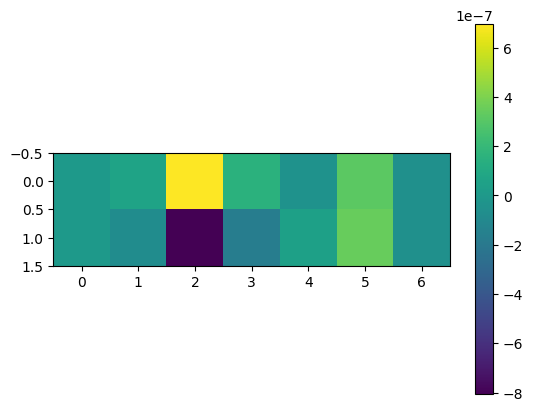

In [42]:
plt.imshow((Aopt @ construct_M(all_linear_pars, n_params=n_params)))
plt.colorbar()

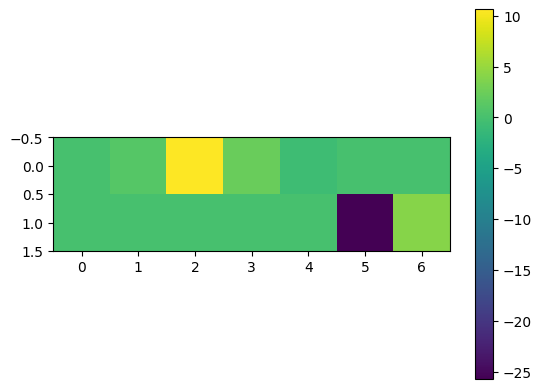

In [43]:
plt.imshow(construct_M(all_linear_pars, n_params=n_params))
plt.colorbar()

In [109]:
get_pruned_expressions(np.eye(n_params), 
                      all_param_dicts,
                       all_pars, all_linear_pars, all_expr, all_linear_labels, remove_floats=False, threshold=1e-20, n_params=n_params
                       )


(['(2.284*X1 + 10.632*exp(0.24*X2) - 0.619)*exp(-0.24*X2)',
  '4.087*log(116.639*X1**2 + 811.204*X2) - 25.736'],
 [[2.284, 10.632, 0.24, 0.619, -0.24], [4.087, 116.639, 811.204, 25.736]])

In [110]:
sr_exprs_vanilla, _ = get_pruned_expressions_final(np.eye(n_params), 
                      all_param_dicts,
                       all_pars, all_linear_pars, 
                       all_expr, all_linear_labels, 
                       remove_floats=False, threshold=0.05, n_params=n_params, X=X_test, Fs=Fs_test
                       )

Looking at component 0
  delta: 0.000000
  zeroed component -> skip!
  delta: 0.000000
  delta: 16579831.000000
  delta: -0.011064
Looking at component 1
  delta: 0.000000
  zeroed component -> skip!


In [118]:
sr_exprs_vanilla

['2.284*X1*exp(-0.24*X2)', '4.087*log(116.639*X1**2 + 811.204*X2)']

In [119]:
sr_exprs_vanilla

['2.284*X1*exp(-0.24*X2)', '4.087*log(116.639*X1**2 + 811.204*X2)']

In [48]:
fit_exprs0, _ = get_pruned_expressions(Aopt, all_param_dicts,
            all_pars, all_linear_pars, all_expr, all_linear_labels, remove_floats=False, threshold=0.1, decimal=3, n_params=n_params)

In [49]:
fit_exprs0

['0', '0']

In [45]:
fit_exprs

['0.01*X2 + 0.01*(-0.69*X2 + exp(0.18*X3))**0.5 + 0.42*(-0.4*X2 + 0.11*X3 + 1)**0.5 + 0.23*exp(0.1*X1)',
 '0.02*X2 - 0.21*(-0.69*X2 + exp(0.18*X3))**0.5 + 1.58*(-0.4*X2 + 0.11*X3 + 1)**0.5 + 0.85*exp(0.1*X1)',
 '0.48*X2 + 0.01*(-0.69*X2 + exp(0.18*X3))**0.5 - 0.33*(-0.4*X2 + 0.11*X3 + 1)**0.5 - 0.18*exp(0.1*X1)']

In [54]:

check_flats = lambda c: check_flattening(c, X=X, Fs=Fs)

In [120]:
n_d = 1
mdl_flats, mdl_J = check_flats(mdl_coords)
frob_flats, frob_J = check_flats(frob_coords)

In [121]:
from copy import deepcopy
fit_exprs2 = deepcopy(sr_exprs_vanilla)

# substitute in mdl coordinates for zero components
# fit_exprs2[1] ="0.0" 
# fit_exprs2[0] = "0.0"

fit_exprs2, mdl_coords

(['2.284*X1*exp(-0.24*X2)', '4.087*log(116.639*X1**2 + 811.204*X2)'],
 ['(10.347089 + (1.000000 * ((exp(((-0.243016) * X2)) * (exp((0.030135 * X1)) ^ ((-0.422953) * X1))) * (2.789157 * X1))))',
  '((-26.317766) + (4.377672 * sqrt(sqrt(sqrt(((2969345.250000 * X2) + ((119.890717 * X1) * (3511.637695 * X1))))))))'])

In [122]:
n_params

In [123]:
n_d = 1
# fit_expr_flats0, _ = check_flats(fit_exprs0)
sr_expr_flats, _ = check_flats(sr_exprs_vanilla)

# fit_expr_flats, _ = check_flattening(fit_exprs, X=X, Fs=Fs)


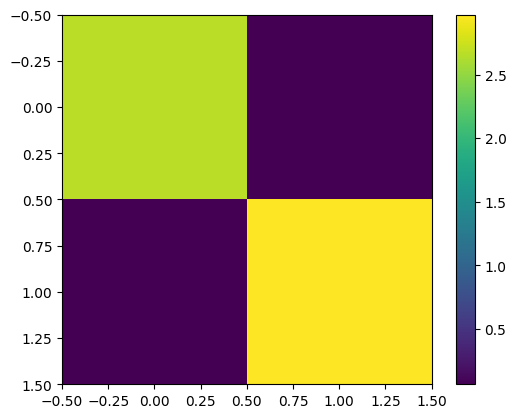

In [124]:
plt.imshow(Fs.mean(0))
plt.colorbar()

In [125]:
sr_exprs_vanilla

['2.284*X1*exp(-0.24*X2)', '4.087*log(116.639*X1**2 + 811.204*X2)']

In [126]:
from sr_utils import norm

In [127]:
jax.vmap(norm)(sr_expr_flats - jnp.eye(n_params)).mean()

Array(1.0921936, dtype=float32)

In [128]:
jax.vmap(norm)(mdl_flats - jnp.eye(n_params)).mean()

Array(1.0131187, dtype=float32)

In [129]:
jax.vmap(norm)(sr_expr_flats - jnp.eye(n_params)).mean()

Array(1.0921936, dtype=float32)

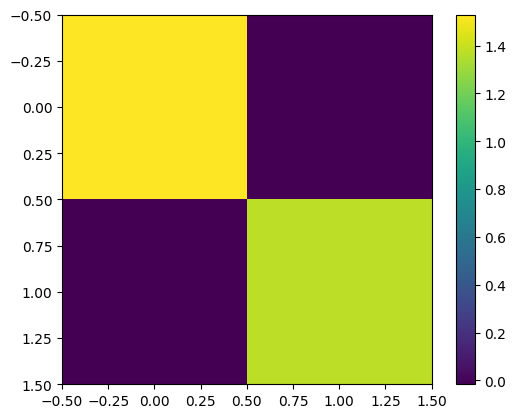

In [130]:
plt.imshow(mdl_flats.mean(0))
plt.colorbar()

In [131]:
mdl_flats = jax.vmap(flatten_with_numerical_jacobian)(mdl_J, Fs)
frob_flats = jax.vmap(flatten_with_numerical_jacobian)(frob_J, Fs)

In [132]:
mdl_flats.mean(0), frob_flats.mean(0)

(Array([[ 1.5291505 , -0.01590682],
        [-0.01590682,  1.3730836 ]], dtype=float32),
 Array([[ 1.5300236 , -0.01392357],
        [-0.01392358,  1.2891414 ]], dtype=float32))

In [133]:
#@title fisher code
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

def plot_fisher_ellipse(fisher_matrix, mean=None, ax=None, color='blue', 
                        alpha=1.0, linestyle='-',
                       label=""):
    """
    Plots a Fisher information matrix ellipse.

    Parameters:
        fisher_matrix (numpy.ndarray): Fisher information matrix.
        mean (numpy.ndarray, optional): Mean vector. Defaults to None, in which case the ellipse will be centered at (0, 0).
        ax (matplotlib.axes.Axes, optional): Axes to plot on. If not provided, a new figure will be created.
        color (str, optional): Color of the ellipse. Defaults to 'blue'.
        alpha (float, optional): Transparency of the ellipse. Defaults to 0.5.
        linestyle (str, optional): Linestyle of the ellipse. Defaults to '-'.

    Returns:
        matplotlib.axes.Axes: Axes object with the ellipse plotted.
    """
    if ax is None:
        _, ax = plt.subplots()

    # Invert the Fisher information matrix to get the covariance matrix
    covariance_matrix = np.linalg.inv(fisher_matrix)

    # Calculate eigenvalues and eigenvectors of the covariance matrix
    eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    # Calculate ellipse angle
    angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))

    # If mean is provided, set the center of the ellipse accordingly
    if mean is not None:
        center = mean
    else:
        center = np.zeros_like(covariance_matrix.shape[0])

    # Create ellipse for 1-sigma contour
    ellipse = Ellipse(xy=center,
                      width=2 * np.sqrt(eigenvalues[0]),
                      height=2 * np.sqrt(eigenvalues[1]),
                      angle=angle,
                      edgecolor=color,
                      linestyle=linestyle,
                      facecolor='none',
                      alpha=alpha,
                      label=label)

    # Create ellipse for 2-sigma contour
    ellipse2 = Ellipse(xy=center,
                       width=2 * 2 * np.sqrt(eigenvalues[0]),
                       height=2 * 2 * np.sqrt(eigenvalues[1]),
                       angle=angle,
                       edgecolor=color,
                       linestyle=linestyle,
                       facecolor='none',
                       alpha=alpha)

    ax.add_patch(ellipse)
    ax.add_patch(ellipse2)
    #ax.set_aspect('equal', 'box')
    ax.autoscale()
    return ax

In [134]:
#nn_flats = jax.vmap(jax.vmap(flatten_with_numerical_jacobian))(dys, ensemble_Fs).mean(0)

nn_flats = jax.vmap(flatten_with_numerical_jacobian)(dy, Fs)

In [135]:
Fs, dy

(array([[[ 7.3441887 ,  0.2790742 ],
         [ 0.2790742 ,  7.7022343 ]],
 
        [[ 2.01313   ,  0.0462712 ],
         [ 0.0462712 ,  2.1302192 ]],
 
        [[ 7.052236  ,  0.2725652 ],
         [ 0.2725652 ,  7.321919  ]],
 
        ...,
 
        [[10.256169  ,  0.17793716],
         [ 0.17793716,  9.701494  ]],
 
        [[ 0.61507845, -0.04712016],
         [-0.04712016,  0.8036616 ]],
 
        [[ 0.98566407,  0.02781254],
         [ 0.02781254,  1.156457  ]]], dtype=float32),
 array([[[ 2.0484421 ,  1.0292342 ],
         [-0.75015426,  2.4707854 ]],
 
        [[ 0.7201052 , -1.0469882 ],
         [ 1.1039982 ,  0.88857794]],
 
        [[ 1.9741958 ,  0.32559344],
         [-0.01545989,  2.4373372 ]],
 
        ...,
 
        [[ 1.3034734 ,  2.1155016 ],
         [-2.3626308 ,  1.4944614 ]],
 
        [[ 0.69963723,  0.29743013],
         [-0.29860437,  0.8271354 ]],
 
        [[ 0.8737159 , -0.42418587],
         [ 0.42431158,  0.9622005 ]]], dtype=float32))

In [136]:
nn_flats = jax.vmap(flatten_with_numerical_jacobian)(dy, Fs)
nn_flats.mean(0)

Array([[ 1.3448535 , -0.01828764],
       [-0.01828764,  1.2221783 ]], dtype=float32)

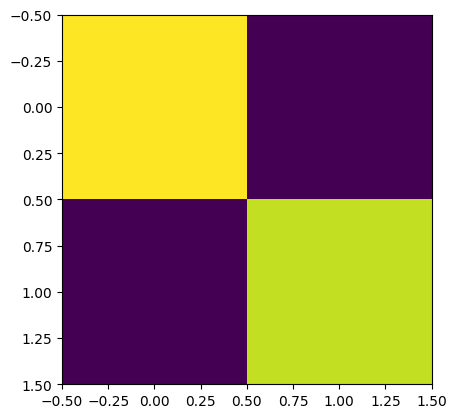

In [137]:
plt.imshow(nn_flats.mean(0))

In [138]:
from preprocessing_utils import get_eigenvalues as get_evalues
evalues_nn = jax.vmap(get_evalues)(nn_flats)
evalues_mdl = jax.vmap(get_evalues)(mdl_flats)
evalues_frob = jax.vmap(get_evalues)(frob_flats)

evalues_fitexpr = jax.vmap(get_evalues)(sr_expr_flats)

In [139]:
evalues_fitexpr

Array([[0.9736265 , 1.9943542 ],
       [0.8971445 , 1.1921172 ],
       [0.78555346, 2.4098856 ],
       ...,
       [1.5237725 , 2.838608  ],
       [0.9266741 , 1.3764104 ],
       [1.1153396 , 1.3131834 ]], dtype=float32)

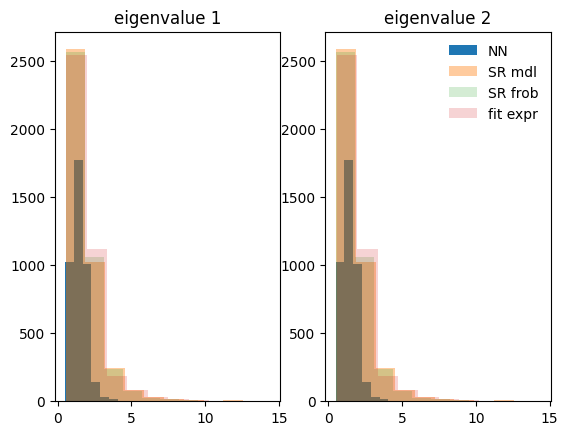

In [140]:
plt.subplot(121)
plt.title("eigenvalue 1")

plt.hist(evalues_nn[:, 3], label="NN")
plt.hist(evalues_mdl[:, 3], alpha=0.4, label="SR mdl")
plt.hist(evalues_frob[:, 3], alpha=0.2, label="SR frob")
plt.hist(evalues_fitexpr[:, 3], alpha=0.2, label="fit expr")


plt.subplot(122)
plt.title("eigenvalue 2")
plt.hist(evalues_nn[:, 1], label="NN")
plt.hist(evalues_mdl[:, 1], alpha=0.4, label="SR mdl")
plt.hist(evalues_frob[:, 1], alpha=0.2, label="SR frob")
plt.hist(evalues_fitexpr[:, 1], alpha=0.2, label="fit expr")


plt.legend(framealpha=0.0)

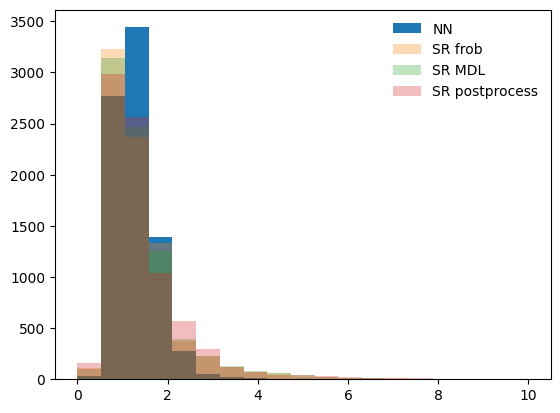

In [141]:
bins = np.linspace(0, 10, 20)
plt.hist(np.array(evalues_nn).flatten(), bins=bins, label='NN')
plt.hist(np.array(evalues_frob).flatten(), bins=bins, alpha=0.3, label='SR frob')
plt.hist(np.array(evalues_mdl).flatten(), bins=bins, alpha=0.3, label='SR MDL')
plt.hist(np.array(evalues_fitexpr).flatten(), bins=bins, alpha=0.3, label='SR postprocess')
plt.legend(framealpha=0.0)

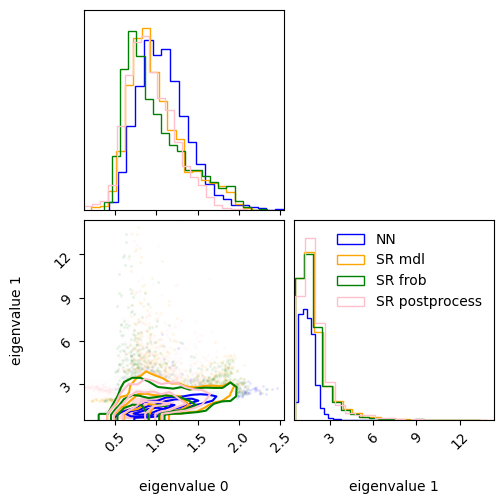

In [142]:
import corner

cols = ['eigenvalue %d'%(i) for i in range(n_params)]

figure = corner.corner(np.array(evalues_nn), color="blue", labels=cols, hist_kwargs=dict(label="NN"))
figure = corner.corner(np.array(evalues_mdl), color="orange", fig=figure, labels=cols, alpha=0.2, hist_kwargs=dict(label="SR mdl"))
figure = corner.corner(np.array(evalues_frob), color="green", fig=figure, labels=cols, alpha=0.2, hist_kwargs=dict(label="SR frob"))
figure = corner.corner(np.array(evalues_fitexpr), color="pink", fig=figure, labels=cols, alpha=0.2, hist_kwargs=dict(label="SR postprocess"))


plt.legend(framealpha=0.0)


In [143]:
nn_flats

Array([[[ 1.47536   , -0.16585676],
        [-0.16585672,  1.1438423 ]],

       [[ 1.2699085 ,  0.0482179 ],
        [ 0.04821789,  1.0485225 ]],

       [[ 1.8066304 , -0.1751122 ],
        [-0.1751122 ,  1.2470645 ]],

       ...,

       [[ 1.6231841 , -0.0640635 ],
        [-0.06406358,  1.2726067 ]],

       [[ 1.0530154 , -0.01459936],
        [-0.01459939,  1.0490203 ]],

       [[ 1.0540183 , -0.00773111],
        [-0.00773114,  1.0374398 ]]], dtype=float32)

In [144]:
nn_flats[:, [0,1],].shape

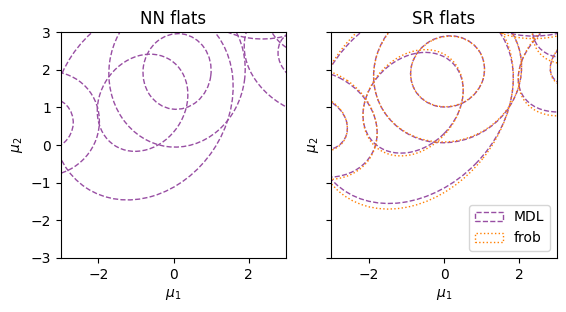

In [146]:
# plot a smattering of fishers

randidx = np.random.choice(500, size=(12), replace=False)


_, axs = plt.subplots(1, 2, sharey=True) 


comps_to_plot = [0,1]

ax = axs[0]

for i,r in enumerate(randidx):
    if i == 0:
        ax = plot_fisher_ellipse(nn_flats[:, comps_to_plot, :][:, :, comps_to_plot][r],ax=ax, mean=X_test[r], color=cm(3), linestyle='--')

    else: 
        if i == len(randidx) - 1:
            labels = ["MDL", "score"]
        else:
            labels = [None, None]
            
        plot_fisher_ellipse(nn_flats[:, comps_to_plot, :][:, :, comps_to_plot][r], mean=X_test[:, comps_to_plot][r], ax=ax, label=labels[0], linestyle='--', color=cm(3))
        #plot_fisher_ellipse(score_flats[r], mean=X[r], ax=ax, label=labels[1], linestyle=':', color=cm(2))



ax.set_ylabel(r"$\mu_2$")
ax.set_xlabel(r"$\mu_1$")
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_title("NN flats")
ax.set_box_aspect(1)
ax = axs[1]

mdl_evalues = []

for i,r in enumerate(randidx):
    if i == 0:
        ax = plot_fisher_ellipse(mdl_flats[:, comps_to_plot, :][:, :, comps_to_plot][r],ax=ax, mean=X_test[:, comps_to_plot][r], color=cm(3), linestyle='--')

    else: 
        if i == len(randidx) - 1:
            labels = ["MDL", "frob"]
        else:
            labels = [None, None]
        
        plot_fisher_ellipse(mdl_flats[:, comps_to_plot, :][:, :, comps_to_plot][r], mean=X_test[r], ax=ax, label=labels[0], linestyle='--', color=cm(3))


for i,r in enumerate(randidx):
    if i == 0:
        ax = plot_fisher_ellipse(frob_flats[:, comps_to_plot, :][:, :, comps_to_plot][r],ax=ax, mean=X_test[:, comps_to_plot][r], color=cm(3), linestyle='--')

    else: 
        if i == len(randidx) - 1:
            labels = ["MDL", "frob"]
        else:
            labels = [None, None]
        
        plot_fisher_ellipse(frob_flats[:, comps_to_plot, :][:, :, comps_to_plot][r], mean=X_test[:, comps_to_plot][r], ax=ax, label=labels[1], linestyle=':', color=cm(4))



ax.set_ylabel(r"$\mu_2$")
ax.set_xlabel(r"$\mu_1$")
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_title("SR flats")

ax.set_box_aspect(1)


plt.legend()

#plt.tight_layout()

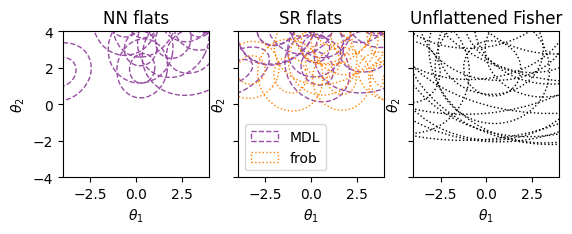

In [147]:
# plot a smattering of fishers

randidx = np.random.choice(500, size=(12), replace=False)


comps_to_plot = [0,1]


_, axs = plt.subplots(1, 3, sharey=True)


ax = axs[0]

for i,r in enumerate(randidx):
    if i == 0:
        ax = plot_fisher_ellipse(nn_flats[:, comps_to_plot, :][:, :, comps_to_plot][r],ax=ax, mean=X[:, comps_to_plot][r], color=cm(3), linestyle='--')

    else: 
        if i == len(randidx) - 1:
            labels = ["MDL", "score"]
        else:
            labels = [None, None]
            
        plot_fisher_ellipse(nn_flats[:, comps_to_plot, :][:, :, comps_to_plot][r], mean=X_test[:, comps_to_plot][r], ax=ax, label=labels[0], linestyle='--', color=cm(3))
        #plot_fisher_ellipse(score_flats[r], mean=X[r], ax=ax, label=labels[1], linestyle=':', color=cm(2))



ax.set_ylabel(r"$\theta_2$")
ax.set_xlabel(r"$\theta_1$")
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_title("NN flats")
ax.set_box_aspect(1)
ax = axs[1]

mdl_evalues = []

for i,r in enumerate(randidx):
    if i == 0:
        ax = plot_fisher_ellipse(mdl_flats[:, comps_to_plot, :][:, :, comps_to_plot][r],ax=ax, mean=X_test[:, comps_to_plot][r], color=cm(3), linestyle='--')

    else: 
        if i == len(randidx) - 1:
            labels = ["MDL", "frob"]
        else:
            labels = [None, None]
        
        plot_fisher_ellipse(mdl_flats[:, comps_to_plot, :][:, :, comps_to_plot][r], mean=X_test[:, comps_to_plot][r], ax=ax, label=labels[0], linestyle='--', color=cm(3))


for i,r in enumerate(randidx):
    if i == 0:
        ax = plot_fisher_ellipse(frob_flats[:, comps_to_plot, :][:, :, comps_to_plot][r],ax=ax, mean=X_test[:, comps_to_plot][r], color=cm(3), linestyle='--')

    else: 
        if i == len(randidx) - 1:
            labels = ["MDL", "frob"]
        else:
            labels = [None, None]
        
        plot_fisher_ellipse(frob_flats[:, comps_to_plot, :][:, :, comps_to_plot][r], mean=X[:, comps_to_plot][r], ax=ax, label=labels[1], linestyle=':', color=cm(4))

ax.legend()

ax.set_ylabel(r"$\theta_2$")
ax.set_xlabel(r"$\theta_1$")
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_title("SR flats")


ax.set_box_aspect(1)




ax = axs[2]

for i,r in enumerate(randidx):
    if i == 0:
        ax = plot_fisher_ellipse(Fs_test[:, comps_to_plot, :][:, :, comps_to_plot][r]*50,ax=ax, mean=X_test[:, comps_to_plot][r], color='k', linestyle=':')

    else: 
        if i == len(randidx) - 1:
            labels = ["MDL", "frob"]
        else:
            labels = [None, None]
            
        plot_fisher_ellipse(Fs_test[:, comps_to_plot, :][:, :, comps_to_plot][r] / 10., mean=X_test[:, comps_to_plot][r], ax=ax, label=labels[1], linestyle=':', color='k')
        #plot_fisher_ellipse(score_flats[r], mean=X[r], ax=ax, label=labels[1], linestyle=':', color=cm(2))




ax.set_ylabel(r"$\theta_2$")
ax.set_xlabel(r"$\theta_1$")
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_title("Unflattened Fisher")
ax.set_box_aspect(1)



#plt.tight_layout()

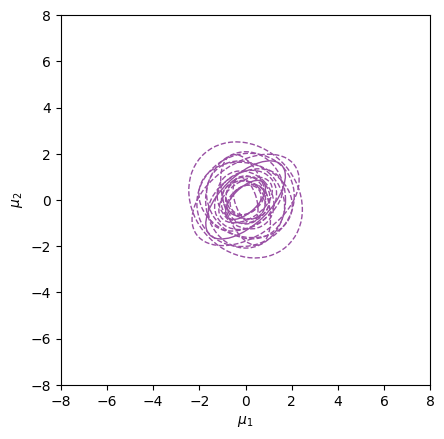

In [148]:
# plot a smattering of fishers

randidx = np.random.choice(1000, size=(10), replace=False)


for i,r in enumerate(randidx):
    if i == 0:
        ax = plot_fisher_ellipse(mdl_flats[:, comps_to_plot, :][:, :, comps_to_plot][r], mean=np.array([0, 0]), color=cm(3))

    else: 
        if i == len(randidx) - 1:
            labels = ["MDL", "score"]
        else:
            labels = [None, None]
            
        plot_fisher_ellipse(mdl_flats[:, comps_to_plot, :][:, :, comps_to_plot][r], mean=np.array([0, 0]), ax=ax, label=labels[0], linestyle='--', color=cm(3))
        #plot_fisher_ellipse(score_flats[r], mean=np.array([0, 0]), ax=ax, label=labels[1], linestyle=':', color=cm(2))

ax.set_ylabel(r"$\mu_2$")
ax.set_xlabel(r"$\mu_1$")
ax.set_xlim(-8,8)
ax.set_ylim(-8, 8)
ax.set_box_aspect(1)
#plt.legend()

# check against geodesic normal coords

In [149]:
# insert Deaglan's and Ben's coordinates

ad_hoc_coords = ['X1 * (1. / sqrt(X2)) * sqrt(50.)', 'log(X2) * sqrt(50.)']

# now geodesic normal coordinates

theta_star = np.array([0.0, 1.0])

def get_geo_coordinates(X, theta_star=theta_star):
    x1, x2 = X

    mu = x1
    sg = x2

    sg_star = (theta_star[1])
    mu_star = theta_star[0]
    
    beta = jnp.arcsinh( 
        ((1./(2. * sg_star * sg)) ) \
                * ((0.5 * (mu - mu_star)**2 + (sg - sg_star)**2)
                       * (0.5 * (mu - mu_star)**2 + (sg + sg_star)**2))**0.5
    )

    eta = jnp.where((mu == mu_star), jnp.sqrt(2.0) * beta * jnp.sign(0.5 * (mu - mu_star)**2 + sg**2 - sg_star**2),
                   0.5 * (mu - mu_star)**2 + sg**2 - sg_star**2 \
                      * jnp.sign(0.5 * (mu - mu_star)**2 + sg**2 - sg_star**2)
    ) # \eta

    # y1 = 0.5 * (mu - mu_star)**2 + sg**2 - sg_star**2 \
    #                  * jnp.sign(0.5 * (mu - mu_star)**2 + sg**2 - sg_star**2)
    
    xi = jnp.where((mu == mu_star), 0.0, 
                   sg_star * (mu - mu_star) * jnp.sqrt(2.0) * jnp.sign(mu - mu_star)
    ) # \xi

    # y2 = sg_star * (mu - mu_star) * jnp.sqrt(2.0) * jnp.sign(mu - mu_star)

    return jnp.array([xi, eta]) #/ jnp.sqrt(50.)



def get_beta(X, theta_star=theta_star, return_beta=False):

    x1,x2 = X
    mu = x1
    sg = x2

    sg_star = (theta_star[1])
    mu_star = theta_star[0]
    
    beta = jnp.arcsinh( 
        ((1./(2. * sg_star * sg)) ) \
                * ((0.5 * (mu - mu_star)**2 + (sg - sg_star)**2)
                       * (0.5 * (mu - mu_star)**2 + (sg + sg_star)**2))**0.5

    )
    if return_beta:
        return ((jnp.sinh(beta)**2.0) / beta**2.0) - 1.0, beta
    else:
        return ((jnp.sinh(beta)**2.0) / beta**2.0) - 1.0  #(1./3.) * beta**2


geo_coordinates = ['0.5 * (X1 - 0.)^2 + X2 - 1.0', '1.0 * (X1 - 0.) * sqrt(2.)']







# FUNCTIONS FOR CHECKING THE FLATNESS OF NEURAL AND NUMERICAL FNs

n_params = 2

frobenius_norm_loss = lambda q: norm((q - jnp.eye(n_params))) #+ norm((jnp.linalg.inv(q) - jnp.eye(n_params)))


def check_neural_flattening(Js, Fs, get_frob=True):
    flats = jax.vmap(flatten_with_numerical_jacobian)(Js, Fs)

    if get_frob:
        return flats, jax.vmap(frobenius_norm_loss)(flats).mean()
    else:
        return flats


def flatten_with_fn(X, F, myfunc=get_geo_coordinates):    
    J_eta = jax.jacobian(myfunc)(X)
    Jeta_inv = jnp.linalg.pinv(J_eta)

    Q = Jeta_inv.T @ F @ Jeta_inv # REVERSED THIS FOR ANALYTIC CONVENTION

    return Q

def check_numerical_fn_flattening(Xs, Fs, get_frob=True, myfunc=get_geo_coordinates):

    flatfn = lambda x,f: flatten_with_fn(x,f, myfunc=myfunc)
    flats = jax.vmap(flatfn)(Xs, Fs)

    if get_frob:
        return flats, jax.vmap(frobenius_norm_loss)(flats)
    else:
        return flats


def get_evalues(M):
    eigenvalues, eigenvectors = jnp.linalg.eigh(M)
    
    return eigenvalues[eigenvalues.argsort()]



In [150]:
sigma_star = 1.0
mu_star = 0.0

u_star = mu_star / sigma_star
v_star = jnp.sqrt(2)

def x_to_sinhbeta(x):
    sinh_beta = jnp.sqrt(
            (0.5 * (x[0] - mu_star)**2 + (x[1] - sigma_star)**2) *
            (0.5 * (x[0] - mu_star)**2 + (x[1] + sigma_star)**2)
        ) / x[1] / sigma_star / 2
    return sinh_beta


def xp_to_beta(xp):
    xi, eta = xp
    beta = jnp.sqrt(xi**2 + eta**2) / v_star
    return beta


def get_beta(X, return_beta=False):    
    xp = x_to_xprime(X)
    beta = xp_to_beta(xp)

    if return_beta:
        return ((jnp.sinh(beta)**2.0) / beta**2.0) - 1.0, beta
    else:
        return ((jnp.sinh(beta)**2.0) / beta**2.0) - 1.0  #(1./3.) * beta**2
    

def x_to_xprime(x):
    sinh_beta = x_to_sinhbeta(x)
    beta = jnp.arcsinh(sinh_beta)
    
    xi = jnp.where(jnp.abs(beta) > 1e-4,
                   beta * (x[0] - mu_star) / x[1] / sinh_beta,
                    0,
    )
    eta = jnp.where(jnp.abs(beta) > 1e-4,
                xi * (0.5 * (x[0] - mu_star)**2 + x[1] ** 2 - sigma_star**2) / 
                (sigma_star * (x[0] - mu_star) * jnp.sqrt(2)),
                0,
    )
    xprime = jnp.array([xi, eta])
    return xprime


def xprime_to_x(xp):

    beta = xp_to_beta(xp)
    xi, eta = xp
    u = jnp.where(beta == 0,
                   u_star,
                    (u_star + 
                        v_star * xi * jnp.sinh(beta) / 
                        (beta * v_star * jnp.cosh(beta) - eta * jnp.sinh(beta))
                    )
    )

    v = jnp.where(beta == 0,
                    v_star,
                    v_star * (
                        beta * v_star / 
                        (beta * v_star * jnp.cosh(beta) - eta * jnp.sinh(beta))
                    )
    )

    x = jnp.array([u * sigma_star, v * sigma_star / jnp.sqrt(2)])

    return x

def metric_fn(x):
    g = jnp.zeros((2, 2))
    g = g.at[0, 0].set(1 / x[1] ** 2)
    g = g.at[1, 1].set(2 / x[1] ** 2)
    return g


def transformed_metric(xp):
    x = xprime_to_x(xp)
    J = jax.jacfwd(x_to_xprime)(x)
    Jinv = jnp.linalg.inv(J)
    g = metric_fn(x)
    return Jinv.T @ g @ Jinv


def predicted_metric(xp):
    beta = xp_to_beta(xp)
    if beta == 0:
        return jnp.eye(2)
    xi, eta = xp
    g = jnp.zeros((2, 2))
    g = g.at[0, 0].set(eta**2 * jnp.sinh(beta)**2 + xi**2 * beta**2)
    g = g.at[0, 1].set(xi * eta * (beta ** 2 - jnp.sinh(beta)**2))
    g = g.at[1, 0].set(g[0, 1])
    g = g.at[1, 1].set(eta**2 * beta **2 + xi**2 * jnp.sinh(beta)**2)
    g = g / 2 / beta ** 4
    return g

In [151]:
# create some true fishers everywhere


def true_fisher(X):
    n_d = 50
    mu = X[0]
    sig = (X[1])
    return n_d * jnp.array([[1./sig**2, 0.0],[0.0, 2. / sig**2]])



true_fs = jax.vmap(true_fisher)(X)

In [152]:
gb = lambda x: get_beta(x, return_beta=True)
_, betas = jax.vmap(gb)(X)


checking against true fishers
---
neural network flattening score: 1.9054285
MDL SR flattening score: 2.018573
Frob SR flattening score: 2.0785182
ad-hoc flattening score: 2.0309575
numerical geo flattening score: 1.6164101
frob norm geo flattening score: 1.6164103


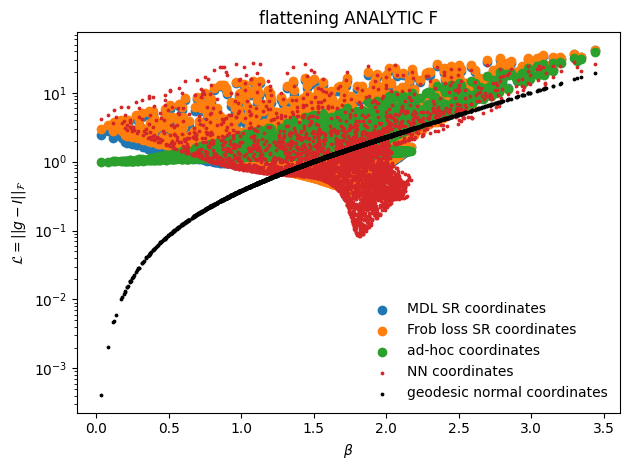

In [153]:
frb = jax.vmap(frobenius_norm_loss)



mdl_losses, _ = check_flattening(mdl_coords, X, Fs=true_fs / norm_factor)
mdl_losses = frb(mdl_losses)
mdl_score = mdl_losses.mean()

frob_losses, _ = check_flattening(frob_coords, X, Fs=true_fs / norm_factor)
frob_losses = frb(frob_losses)
frob_score = frob_losses.mean()

adhoc_losses, _ = check_flattening(ad_hoc_coords, X, Fs=true_fs)
adhoc_losses = frb(adhoc_losses)
adhoc_score = adhoc_losses.mean()

geo_score = frb(check_flattening(geo_coordinates, X, Fs=true_fs)[0]).mean()


# check neural network and numerical geodesic normal coord solution as well
nn_flats_, nn_score = check_neural_flattening(dy, true_fs / norm_factor)
nn_losses = frb(nn_flats_)

geo2_flats, geo2_losses = check_numerical_fn_flattening(X, true_fs / 50, myfunc=x_to_xprime)
geo2_score = geo2_losses.mean()

beta_geo_score = jax.vmap(get_beta)(X).mean()

print("\nchecking against true fishers\n---")
print("neural network flattening score:", nn_score)
print("MDL SR flattening score:", mdl_score)
print("Frob SR flattening score:", frob_score)
print('ad-hoc flattening score:', adhoc_score)
# print('geo flattening score:', geo_score)
print('numerical geo flattening score:', geo2_score)
print('frob norm geo flattening score:', beta_geo_score)


# compare beta vs losses for each type of coord

plt.scatter(betas, mdl_losses, label='MDL SR coordinates')
plt.scatter(betas, frob_losses, label='Frob loss SR coordinates')


plt.scatter(betas, adhoc_losses, label='ad-hoc coordinates')

plt.scatter(betas, nn_losses, label='NN coordinates', s=3)

plt.scatter(betas, geo2_losses, c='k', label='geodesic normal coordinates', s=3)

plt.yscale('log')
plt.ylabel(r'$\mathcal{L} = ||g - I||_\mathcal{F}$')
plt.xlabel(r'$\beta$')
plt.legend(framealpha=0.0)
plt.title('flattening ANALYTIC F')
plt.tight_layout()

# plt.savefig("/Users/lucas/repositories/degeneracy_distillery/plots/mu_sigma_analytic_flattening.pdf", dpi=400)


checking against true fishers
---
neural network flattening score: 0.6022167
MDL SR flattening score: 1.0131187
Frob SR flattening score: 0.9738329
ad-hoc flattening score: 1.0795357
numerical geo flattening score: 9.631397
frob norm geo flattening score: 1.6164103


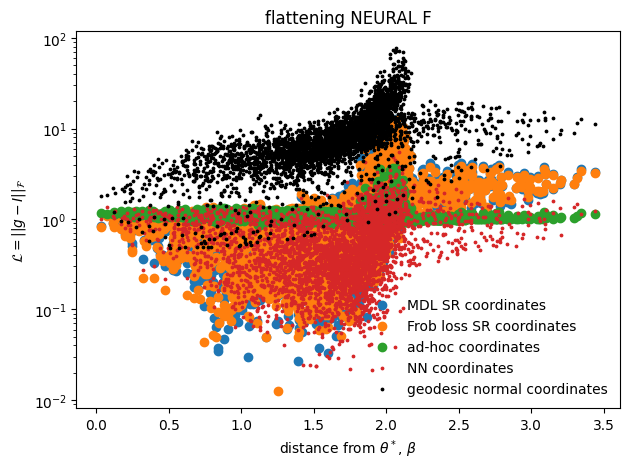

In [154]:

mdl_losses, _ = check_flattening(mdl_coords, X, Fs=Fs)
mdl_losses = frb(mdl_losses)
mdl_score = mdl_losses.mean()

frob_losses, _ = check_flattening(frob_coords, X, Fs=Fs)
frob_losses = frb(frob_losses)
frob_score = frob_losses.mean()

adhoc_losses, _ = check_flattening(ad_hoc_coords, X, Fs=Fs)
adhoc_losses = frb(adhoc_losses)
adhoc_score = adhoc_losses.mean()

geo_score = frb(check_flattening(geo_coordinates, X, Fs=Fs)[0]).mean()


# check neural network and numerical geodesic normal coord solution as well
nn_flats_, nn_score = check_neural_flattening(dy, Fs)
nn_losses = frb(nn_flats_)

geo2_flats, geo2_losses = check_numerical_fn_flattening(X, Fs / norm_factor, myfunc=x_to_xprime)
geo2_score = geo2_losses.mean()

print("\nchecking against true fishers\n---")
print("neural network flattening score:", nn_score)
print("MDL SR flattening score:", mdl_score)
print("Frob SR flattening score:", frob_score)
print('ad-hoc flattening score:', adhoc_score)
# print('geo flattening score:', geo_score)
print('numerical geo flattening score:', geo2_score)
print('frob norm geo flattening score:', beta_geo_score)





plt.scatter(betas, mdl_losses, label='MDL SR coordinates')
plt.scatter(betas, frob_losses, label='Frob loss SR coordinates')


plt.scatter(betas, adhoc_losses, label='ad-hoc coordinates')

plt.scatter(betas, nn_losses, label='NN coordinates', s=3)

plt.scatter(betas, geo2_losses, c='k', label='geodesic normal coordinates', s=3)

plt.yscale('log')
plt.ylabel(r'$\mathcal{L} = ||g - I||_\mathcal{F}$')
plt.xlabel(r'distance from $\theta^*$, $\beta$')
plt.legend(framealpha=0.0)
plt.title('flattening NEURAL F')
plt.tight_layout()


checking against true fishers
---
neural network flattening score: 1.9054285
MDL SR flattening score: 2.018573
Frob SR flattening score: 2.0785182
ad-hoc flattening score: 1.0602272
numerical geo flattening score: 1.6164101
frob norm geo flattening score: 1.6164103

checking against true fishers
---
neural network flattening score: 0.6022167
MDL SR flattening score: 1.0131187
Frob SR flattening score: 0.9738329
ad-hoc flattening score: 1.0795357
numerical geo flattening score: 9.631397
frob norm geo flattening score: 1.6164103


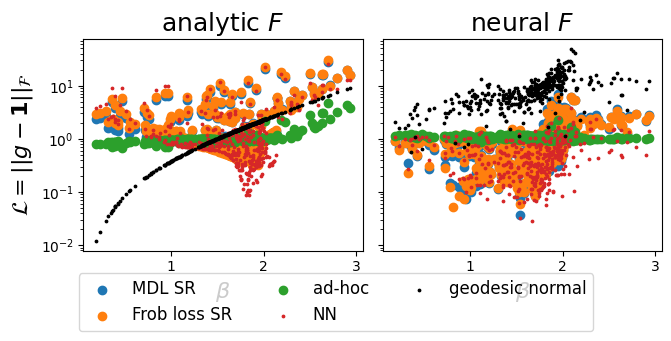

In [155]:
# make two-panel plot:

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(3.41*2., 3.41), sharey=True)


ax = axs[0]

mdl_losses, _ = check_flattening(mdl_coords, X, Fs=true_fs / norm_factor)
mdl_losses = frb(mdl_losses)
mdl_score = mdl_losses.mean()

frob_losses, _ = check_flattening(frob_coords, X, Fs=true_fs / norm_factor)
frob_losses = frb(frob_losses)
frob_score = frob_losses.mean()

adhoc_losses, _ = check_flattening(ad_hoc_coords, X, Fs=true_fs / norm_factor)
adhoc_losses = frb(adhoc_losses)
adhoc_score = adhoc_losses.mean()

geo_score = frb(check_flattening(geo_coordinates, X, Fs=true_fs)[0]).mean()


# check neural network and numerical geodesic normal coord solution as well
nn_flats_, nn_score = check_neural_flattening(dy, true_fs / norm_factor)
nn_losses = frb(nn_flats_)

geo2_flats, geo2_losses = check_numerical_fn_flattening(X, true_fs / 50, myfunc=x_to_xprime)
geo2_score = geo2_losses.mean()

beta_geo_score = jax.vmap(get_beta)(X).mean()

print("\nchecking against true fishers\n---")
print("neural network flattening score:", nn_score)
print("MDL SR flattening score:", mdl_score)
print("Frob SR flattening score:", frob_score)
print('ad-hoc flattening score:', adhoc_score)
# print('geo flattening score:', geo_score)
print('numerical geo flattening score:', geo2_score)
print('frob norm geo flattening score:', beta_geo_score)


# compare beta vs losses for each type of coord
skip = 10

ax.scatter(betas[::skip], mdl_losses[::skip], label='MDL SR')
ax.scatter(betas[::skip], frob_losses[::skip], label='Frob loss SR')


ax.scatter(betas[::skip], adhoc_losses[::skip], label='ad-hoc')

ax.scatter(betas[::skip], nn_losses[::skip], label='NN', s=3)

ax.scatter(betas[::skip], geo2_losses[::skip], c='k', label='geodesic normal', s=3)

ax.set_yscale('log')
ax.set_ylabel(r'$\mathcal{L} = ||g - \mathbf{1}||_\mathcal{F}$', fontsize=16)
ax.set_xlabel(r'$\beta$', fontsize=16)
ax.set_title(r'analytic $F$', fontsize=18)


## SECOND PLOT

ax = axs[1]





mdl_losses, _ = check_flattening(mdl_coords, X, Fs=Fs)
mdl_losses = frb(mdl_losses)
mdl_score = mdl_losses.mean()

frob_losses, _ = check_flattening(frob_coords, X, Fs=Fs)
frob_losses = frb(frob_losses)
frob_score = frob_losses.mean()

adhoc_losses, _ = check_flattening(ad_hoc_coords, X, Fs=Fs)
adhoc_losses = frb(adhoc_losses)
adhoc_score = adhoc_losses.mean()

geo_score = frb(check_flattening(geo_coordinates, X, Fs=Fs)[0]).mean()


# check neural network and numerical geodesic normal coord solution as well
nn_flats_, nn_score = check_neural_flattening(dy, Fs)
nn_losses = frb(nn_flats_)

geo2_flats, geo2_losses = check_numerical_fn_flattening(X, Fs / norm_factor, myfunc=x_to_xprime)
geo2_score = geo2_losses.mean()

print("\nchecking against true fishers\n---")
print("neural network flattening score:", nn_score)
print("MDL SR flattening score:", mdl_score)
print("Frob SR flattening score:", frob_score)
print('ad-hoc flattening score:', adhoc_score)
# print('geo flattening score:', geo_score)
print('numerical geo flattening score:', geo2_score)
print('frob norm geo flattening score:', beta_geo_score)



# compare beta vs losses for each type of coord

line1 = ax.scatter(betas[::skip], mdl_losses[::skip], label='MDL SR')
line2 = ax.scatter(betas[::skip], frob_losses[::skip], label='Frob loss SR')


line3 = ax.scatter(betas[::skip], adhoc_losses[::skip], label='ad-hoc')

line4 = ax.scatter(betas[::skip], nn_losses[::skip], label='NN', s=3)

line5 = ax.scatter(betas[::skip], geo2_losses[::skip], c='k', label='geodesic normal', s=3)

ax.set_yscale('log')
# ax.set_ylabel(r'$\mathcal{L} = ||g - I||_\mathcal{F}$')
ax.set_xlabel(r'$\beta$', fontsize=16)


ax.set_title(r'neural $F$', fontsize=18)



# plt.legend(framealpha=0.0, loc=(0.4,0.1), fontsize=12, ncols=1, bbox_to_anchor=(0.4,0.1))
# ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0., fontsize=12)



# Use fig.legend to center it under both plots
# loc='lower center' tells it to use the bottom of the legend as the anchor
fig.legend(handles=[line1, line2, line3, line4, line5], 
           loc='lower center', 
           ncol=3, 
           fontsize=12,
           bbox_to_anchor=(0.5, -0.01)) # 0.5 is the middle of the whole figure

# Tighten the layout but leave a specific margin at the bottom for the legend
plt.tight_layout(rect=[0, 0.05, 1, 1]) 



# plt.tight_layout()
# # You might need to adjust the bottom margin if the legend is cut off
# plt.subplots_adjust(bottom=0.2)

# plt.tight_layout()


# plt.savefig('/Users/lucas/repositories/degeneracy_distillery/plots/mu_sigma_coordinate_compare.pdf',dpi=100, bbox_inches='tight')
plt.show()
